In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

In [15]:
df=pd.read_csv('HDHI Admission data.csv')
df.head()
df.columns

Index(['SNO', 'MRD No.', 'D.O.A', 'D.O.D', 'AGE', 'GENDER', 'RURAL',
       'TYPE OF ADMISSION-EMERGENCY/OPD', 'month year', 'DURATION OF STAY',
       'duration of intensive unit stay', 'OUTCOME', 'SMOKING ', 'ALCOHOL',
       'DM', 'HTN', 'CAD', 'PRIOR CMP', 'CKD', 'HB', 'TLC', 'PLATELETS',
       'GLUCOSE', 'UREA', 'CREATININE', 'BNP', 'RAISED CARDIAC ENZYMES', 'EF',
       'SEVERE ANAEMIA', 'ANAEMIA', 'STABLE ANGINA', 'ACS', 'STEMI',
       'ATYPICAL CHEST PAIN', 'HEART FAILURE', 'HFREF', 'HFNEF', 'VALVULAR',
       'CHB', 'SSS', 'AKI', 'CVA INFRACT', 'CVA BLEED', 'AF', 'VT', 'PSVT',
       'CONGENITAL', 'UTI', 'NEURO CARDIOGENIC SYNCOPE', 'ORTHOSTATIC',
       'INFECTIVE ENDOCARDITIS', 'DVT', 'CARDIOGENIC SHOCK', 'SHOCK',
       'PULMONARY EMBOLISM', 'CHEST INFECTION'],
      dtype='object')

In [16]:
#check for missing values
df.isnull().sum().sort_values(ascending=False)


BNP                                8441
EF                                 1505
GLUCOSE                             863
TLC                                 286
PLATELETS                           285
HB                                  252
CREATININE                          247
UREA                                241
SNO                                   0
STEMI                                 0
HEART FAILURE                         0
HFREF                                 0
HFNEF                                 0
VALVULAR                              0
CHB                                   0
SSS                                   0
AKI                                   0
CVA INFRACT                           0
CVA BLEED                             0
AF                                    0
VT                                    0
PSVT                                  0
CONGENITAL                            0
UTI                                   0
NEURO CARDIOGENIC SYNCOPE             0


In [20]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_imputer=SimpleImputer(strategy='mean')
categorical_imputer=SimpleImputer(strategy='most_frequent')
df[numerical_cols] = numerical_imputer.fit_transform(df[numerical_cols])
df[categorical_cols] = categorical_imputer.fit_transform(df[categorical_cols])

In [21]:
for c in categorical_cols +['OUTCOME']:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c])

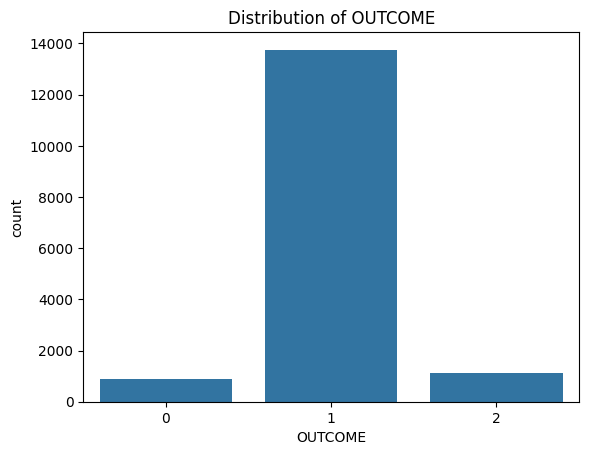

In [22]:
sns.countplot(x='OUTCOME', data=df)
plt.title('Distribution of OUTCOME')
plt.show()

this dataset consist more info about discharged patient

In [ ]:
0 = Expires
1 = Discharged
2 = Transferred

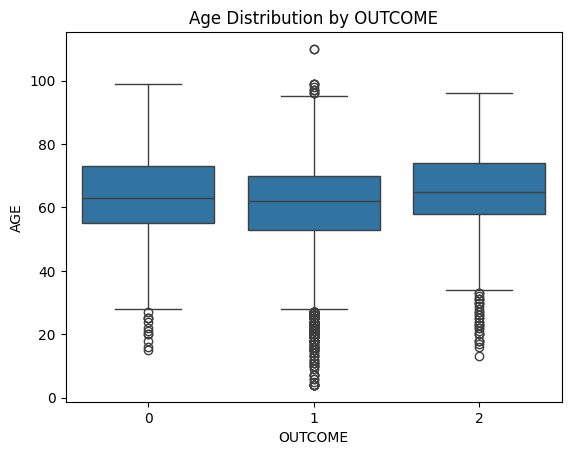

In [24]:
sns.boxplot(x='OUTCOME', y='AGE', data=df)
plt.title('Age Distribution by OUTCOME')
plt.show()

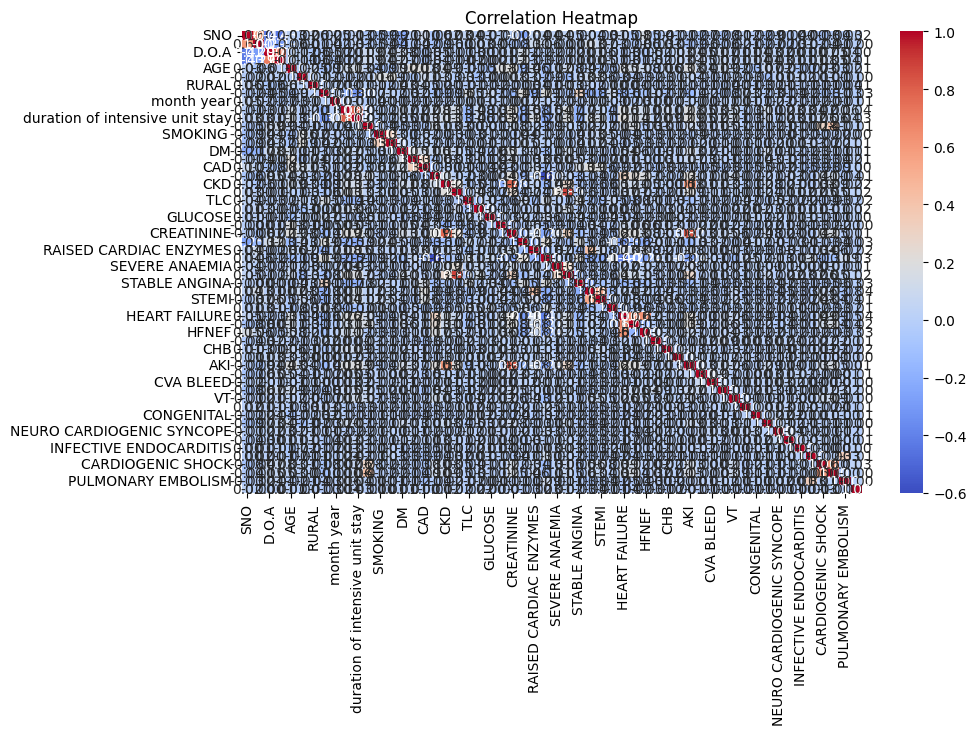

In [26]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
features=['AGE','Gender','HTN',]